# Projeto Integrado - Sprint 6

## 1. - Introdução ao dataset

### 1.1 - Importações

In [ ]:
# leitura de pacotes necessários
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats as st

In [ ]:
# leitura do dataset
df_raw = pd.read_csv('games.csv')

### 1.2 - Primeiras impressões

In [ ]:
# visualização de primeiras linhas
df_raw.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [ ]:
# descoberta de informações gerais sobre o dataframe
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [ ]:
# descoberta de informações relevantes sobre os dados
df_raw.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


Numa primeira análise, foram encontrados problemas na nomenclatura de todas as colunas, pois não atendem ao modelo snake_case. Os tipos de dados em algumas colunas podem ser mais apropriados. Dados ausentes forem encontrados nas colunas Name, Year_of_Release, Genre, Critic_Score, User_Score e Rating.

## 2. - Preparação dos dados

### 2.1 - Correção nomenclatura de colunas

In [ ]:
# salvando nomes das colunas numa nova variável
to_fix_columns = df_raw.columns

In [ ]:
# função para adoção do método snake_case
def rename_columns(columns):
    fixed_columns = list()
    for column in columns:
        column = column.strip().lower().replace(' ', '_')
        fixed_columns.append(column)
    return fixed_columns

In [ ]:
# criação de cópia do df_raw
df_cleaned = df_raw.copy()

# aplicação da função
df_cleaned.columns = rename_columns(to_fix_columns)
df_cleaned.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

### 2.2 - Correção tipos de dados

In [ ]:
# exibindo tipos de dados das colunas
df_cleaned.dtypes

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

In [ ]:
# substituição tbd por NaNs
df_cleaned = df_cleaned.replace('tbd', np.nan)

In [ ]:
# alterando tipo de dado coluna user_score
df_cleaned['user_score'] = df_cleaned['user_score'].astype('float')

### 2.3 Correção strings

In [ ]:
# aplicação método strip e lower a todas as colunas não numéricas
df_cleaned['name'] = df_cleaned['name'].str.strip().str.lower()
df_cleaned['platform'] = df_cleaned['platform'].str.strip().str.lower()
df_cleaned['genre'] = df_cleaned['genre'].str.strip().str.lower()
df_cleaned['rating'] = df_cleaned['rating'].str.strip().str.lower()

### 2.4 - Criação nova coluna

In [ ]:
# criação coluna total_sales
df_cleaned['total_sales'] = df_cleaned['na_sales'] + df_cleaned['eu_sales'] + df_cleaned['jp_sales'] + df_cleaned['other_sales']

### 2.5 - Tratamento valores duplicados

In [ ]:
# contagem valores duplicados
df_cleaned.duplicated().sum()

0

In [ ]:
# teste duplicados por base em colunas identificadoras
df_cleaned[df_cleaned[['name','platform']].duplicated()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
1591,need for speed: most wanted,x360,2005.0,racing,1.0,0.13,0.02,0.10,83.0,8.5,t,1.25
4127,sonic the hedgehog,ps3,NaN,platform,0.0,0.48,0.00,0.00,43.0,4.1,e10+,0.48
11715,need for speed: most wanted,pc,2012.0,racing,0.0,0.06,0.00,0.02,82.0,8.5,t,0.08
14244,NaN,gen,1993.0,NaN,0.0,0.00,0.03,0.00,NaN,NaN,NaN,0.03
16230,madden nfl 13,ps3,2012.0,sports,0.0,0.01,0.00,0.00,83.0,5.5,e,0.01


Optarei pela não exclusão de jogos e plataformas duplicadas pois podem se tratar de um relançamento.

### 2.6 - Tratamento de valores ausentes

In [ ]:
# contagem valores ausentes
df_cleaned.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
total_sales           0
dtype: int64

In [ ]:
def fixing_year(row):
    year = row['year_of_release']
    name = row['name']
    platform = row['platform']

    # se o ano estiver ausente
    if pd.isna(year):
        # tenta encontrar outro registro com o mesmo nome e ano conhecido
        match = df_cleaned[df_cleaned['name'] == name]['year_of_release'].dropna()
        if not match.empty:
            # pega o primeiro valor encontrado
            year = match.iloc[0]
        else:
            # mediana da plataforma em último caso
            year = df_cleaned.groupby('platform')['year_of_release'].median().get(platform, np.nan)

    return year

# execução função
df_cleaned['year_of_release'] = df_cleaned.apply(fixing_year, axis=1)

# mudança tipo de dado
df_cleaned['year_of_release'] = df_cleaned['year_of_release'].astype('int')

In [ ]:
# tratamento coluna name
df_cleaned['name'] = df_cleaned['name'].fillna('unknown')

In [ ]:
# tratamento coluna genre
df_cleaned['genre'] = df_cleaned['genre'].fillna('unknown')

Nesta etapa, foram corrigidos problemas identificados no dataset. A criação da coluna total_sales deve facilitar cálculos. Os motivos da escolha da alteração de dados nas colunas deve simplificar a manipulação de dados. Os dados marcados em TBD foram transformados em NaN para uniformização dos dados desconhecidos. A escolha por eliminar os valores nulos presentes na coluna name e substituir os demais com valores genéricos deve-se a diferença gritante de ocorrências.

## 3. - Análises

### 3.1 - Lançamentos por ano

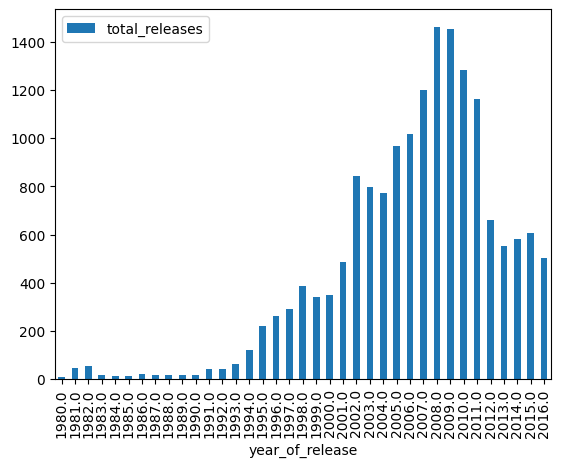

In [ ]:
# agrupamento dados quantidade de lançamentos por ano
fig_31 = df_cleaned.groupby('year_of_release')['name'].count().reset_index()
fig_31 = fig_31.rename(columns={'name':'total_releases'})

# construção gráfico
fig_31.plot(
    kind='bar',
    x='year_of_release'
)

plt.show()

Nota-se uma crescente no número de jogos produzidos até 2007, seguido por uma queda abrupta entre 2011 e 2012. Dali em diante, com oscilações seguindo uma tendência de queda graudal.

### 3.2 - Vendas por plataforma

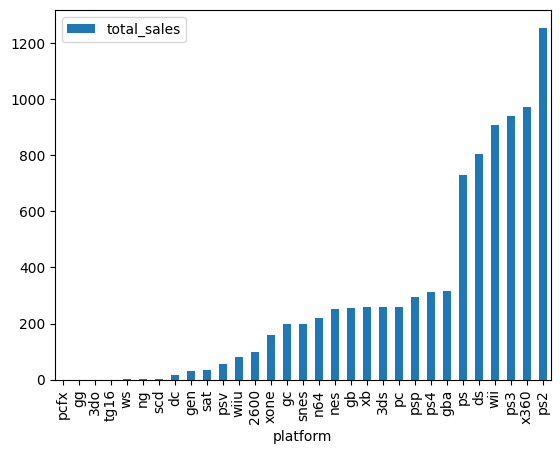

In [ ]:
# agrupamento dados vendas totais por plataforma e ordenação
fig_32 = df_cleaned.groupby('platform')['total_sales'].sum().reset_index()
fig_32 = fig_32.sort_values(by='total_sales')

# construção gráfico
fig_32.plot(
    kind='bar',
    x='platform'
)

plt.show()

As plataformas com maiores números absolutos são PS2, X360, PS3, WII, DS e PSVita.

### 3.3 Vendas plataformas mais populares ao longo do tempo

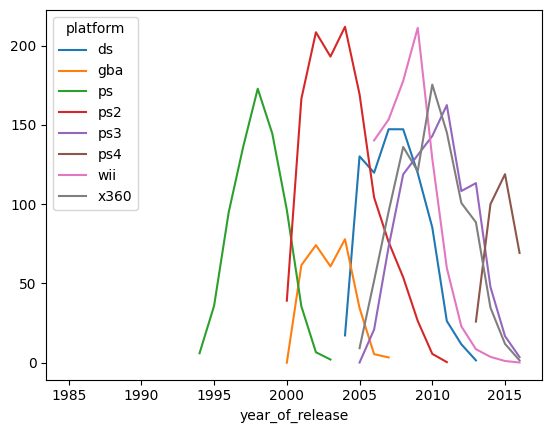

In [ ]:
# variável com plataformas com o maior número de vendas
top_platforms = fig_32['platform'].where(fig_32['total_sales'] > 300).dropna()

# filtro dataframe
df_top_platforms = df_cleaned[df_cleaned['platform'].isin(top_platforms)]

# criação tabela dinâmica
fig_33 = df_top_platforms.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

# construção gráfico
fig_33.plot()

plt.show()

As novas plataformas surgem em média a cada 10 anos, o que leva ao consequentemente leva ao desaparecimento gradual das anteriores por obsolescência.

Para um contexto mais recente, deve-se usar por modelo os dados referentes aos lançamentos dos últimos 3-5 anos.

### 3.4 - Novo df baseado nos últimos 3 anos

In [ ]:
# df filtrado apenas para lançamentos após 2013
df_2 = df_cleaned.copy()
df_2 = df_2[df_2['year_of_release'] >= 2013]
df_2

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,grand theft auto v,ps3,2013.0,action,7.02,9.09,0.98,3.96,97.0,8.2,m,21.05
23,grand theft auto v,x360,2013.0,action,9.66,5.14,0.06,1.41,97.0,8.1,m,16.27
31,call of duty: black ops 3,ps4,2015.0,shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
33,pokemon x/pokemon y,3ds,2013.0,role-playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
42,grand theft auto v,ps4,2014.0,action,3.96,6.31,0.38,1.97,97.0,8.3,m,12.62
...,...,...,...,...,...,...,...,...,...,...,...,...
16703,strawberry nauts,psv,2016.0,adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16707,aiyoku no eustia,psv,2014.0,misc,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16710,samurai warriors: sanada maru,ps3,2016.0,action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16712,haitaka no psychedelica,psv,2016.0,adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01


### 3.5 - Plataformas líderes de venda novo df

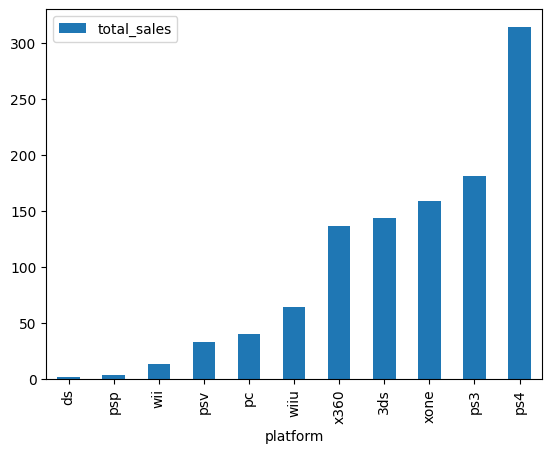

In [ ]:
# agrupamento e ordenação
fig_35 = df_2.groupby('platform')['total_sales'].sum().reset_index()
fig_35 = fig_35.sort_values(by='total_sales')

# construção gráfico
fig_35.plot(
    kind='bar',
    x='platform'
)

plt.show()

O top5 plataformas são PS4 (com ampla vantagem), PS3, Xone, 3DS e X360.

### 3.6 - Vendas top plataformas ao longo do tempo

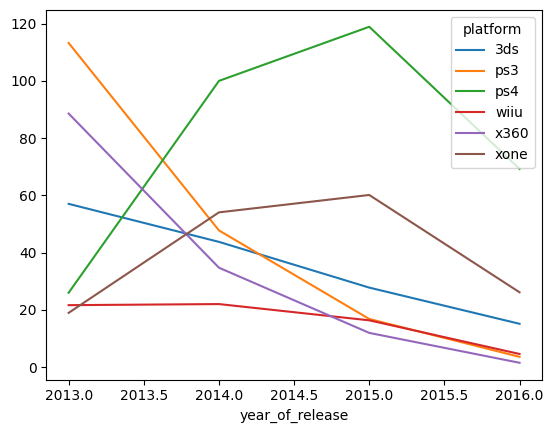

In [ ]:
# variável com plataformas com o maior número de vendas
top_platforms_2 = fig_35['platform'].where(fig_35['total_sales'] > 50).dropna()

# filtro dataframe
df_top_platforms_2 = df_2[df_2['platform'].isin(top_platforms_2)]

# criação tabela dinâmica
fig_36 = df_top_platforms_2.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

# gráfico
fig_36.plot()

plt.show()

De acordo com os últimos 5 anos, todas as top plataformas estão num momento de queda de vendas. Observações a PS4 E XONE que estavam numa crescente até o ano anterior.

### 3.7 - Correlação Vendas e Avaliações

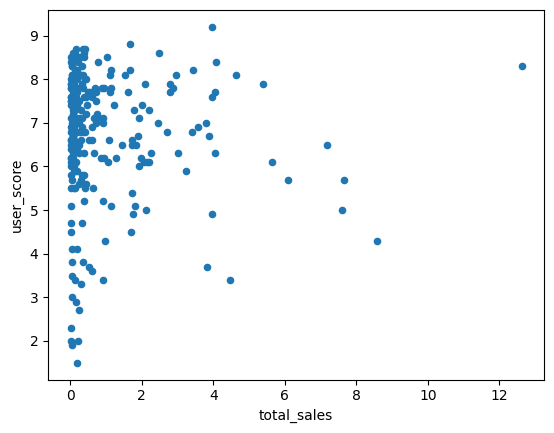

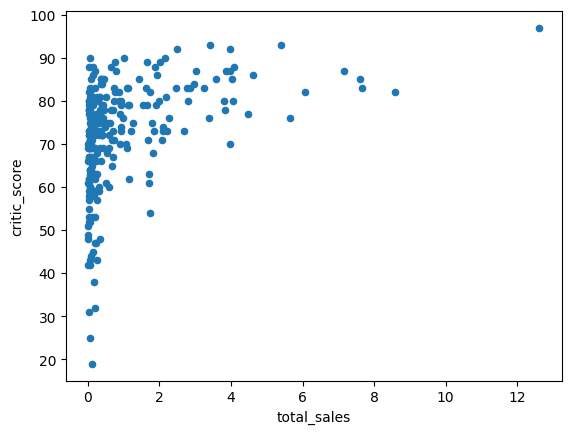

A correlação entre as vendas e nota das crítica é 0.407
A correlação entre as vendas e nota dos usuários é -0.032


In [ ]:
# filtro para amostra plataforma ps4
fig_37 = df_2[df_2['platform'] == 'ps4'][['total_sales', 'user_score', 'critic_score']]

# gráfico correlação usuários
fig_37.plot(
    kind='scatter',
    x='total_sales',
    y='user_score'
)

# gráfico correlação criticos
fig_37.plot(
    kind='scatter',
    x='total_sales',
    y='critic_score'
)

plt.show()

# cálculo correlação
corr_1 = fig_37['total_sales'].corr(fig_37['critic_score'])
corr_2 = fig_37['total_sales'].corr(fig_37['user_score'])

print(f'A correlação entre as vendas e nota das crítica é {corr_1:.3f}')
print(f'A correlação entre as vendas e nota dos usuários é {corr_2:.3f}')

De acordo com a análise matemática realizada, a correlação entre vendas e notas de usuários é negativa praticamente nula, enquanto que a correlação entre vendas e notas da crítica existente é levemente positiva.

### 3.8 - Gêneros mais Lucrativos

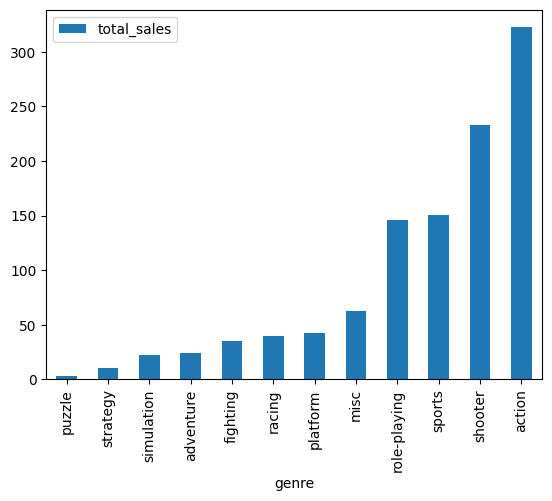

In [ ]:
# agrupando dados
fig_38 = df_2.groupby('genre')['total_sales'].sum().reset_index()
fig_38 = fig_38.sort_values(by='total_sales')

#criação gráfico
fig_38.plot(
    kind='bar',
    x='genre',
    y='total_sales'
)

plt.show()

Os genêros mais lucrativos são action, shooter e sports.

## 4 - Perfis de usuário

### 4.1 - Usuário NA

#### 4.1.1 - Top plataformas NA

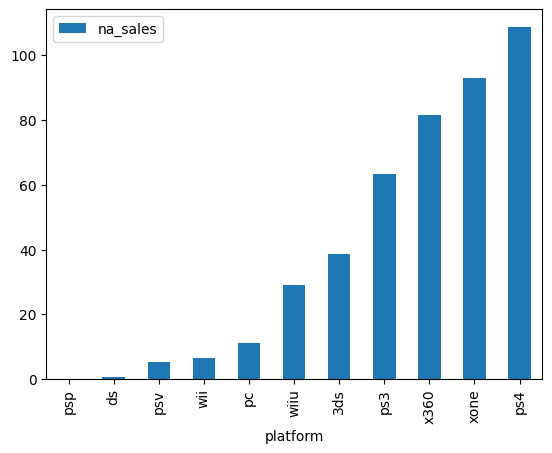

In [ ]:
# agrupamento vendas por plataforma na américa do norte
fig_411 = df_2.groupby('platform')['na_sales'].sum().reset_index()
fig_411 = fig_411.sort_values(by='na_sales')

# construção gráfico
fig_411.plot(
    kind='bar',
    x='platform',
)

plt.show()

As principais plataformas são PS4, X360, Xone, PS3 e 3ds.

#### 4.1.2 - Top genêros NA

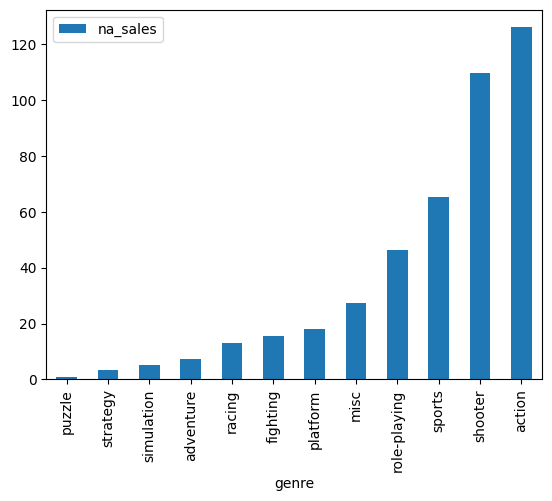

In [ ]:
# agrupamento vendas por gênero na américa do norte
fig_412 = df_2.groupby('genre')['na_sales'].sum().reset_index()
fig_412 = fig_412.sort_values(by='na_sales')

# contrução gráfio
fig_412.plot(
    kind='bar',
    x='genre'
)

plt.show()

Os principais genêros são action, shooter (amplas vantagens), sports, role-playing e misc.

### 4.2 - Usuário UE

#### 4.2.1 - Top plataformas UE

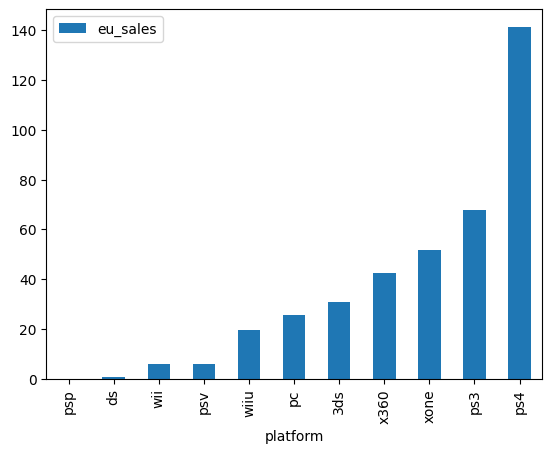

In [ ]:
# agrupamento vendas por plataforma na europa
fig_421 = df_2.groupby('platform')['eu_sales'].sum().reset_index()
fig_421 = fig_421.sort_values(by='eu_sales')

# construção gráfico
fig_421.plot(
    kind='bar',
    x='platform',
)

plt.show()

As principais plataformas na Europa são PS4 (com ampla diferença), PS3, X360, Xone e 3DS.

#### 4.2.2 - Top genêros UE

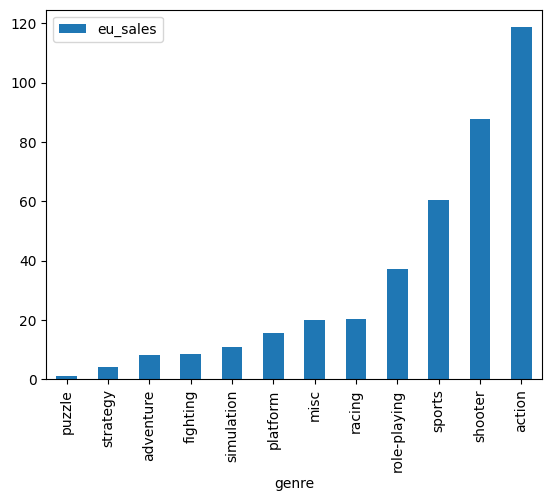

In [ ]:
# agrupamento vendas por gênero na europa
fig_422 = df_2.groupby('genre')['eu_sales'].sum().reset_index()
fig_422 = fig_422.sort_values(by='eu_sales')

# contrução gráfio
fig_422.plot(
    kind='bar',
    x='genre'
)

plt.show()

Os principais genêros na Europa são action, shooter (amplas vantagens), sports, role-playing e racing.

### 4.3 - Usuário  JP

#### 4.3.1 - Top plataformas JP

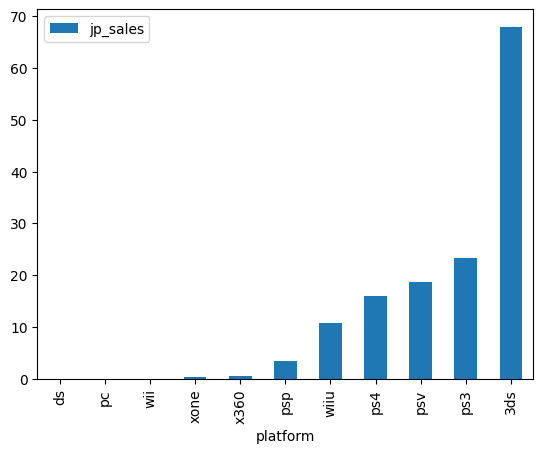

In [ ]:
# agrupamento vendas por plataforma no japão
fig_431 = df_2.groupby('platform')['jp_sales'].sum().reset_index()
fig_431 = fig_431.sort_values(by='jp_sales')

# construção gráfico
fig_431.plot(
    kind='bar',
    x='platform',
)

plt.show()

As principais plataformas do Japão são 3DS (com ampla diferença), PS3, PSV.

#### 4.3.2 - Top genêros JP

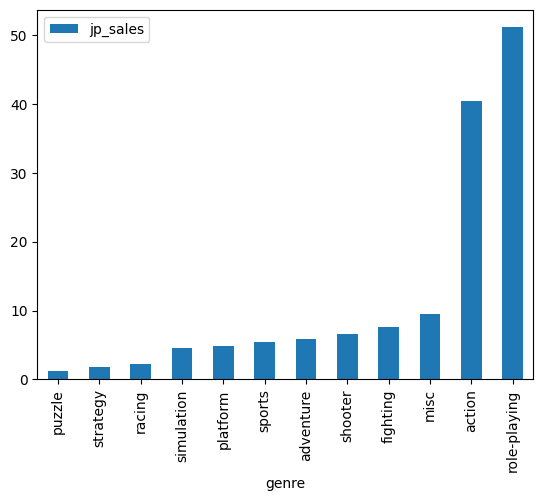

In [ ]:
# agrupamento vendas por gênero no japão
fig_432 = df_2.groupby('genre')['jp_sales'].sum().reset_index()
fig_432 = fig_432.sort_values(by='jp_sales')

# contrução gráfio
fig_432.plot(
    kind='bar',
    x='genre'
)

plt.show()

Os principais genêros no Japão são role-playing, action (amplas vantagens), misc, fighting e shooter.

## 5 - Teste de hipóteses

### 5.1 - Classificação média entre plataformas por usuários

In [ ]:
# filtro coluna criticos para as plataformas especificadas
obj_51_pc = df_2['user_score'].where(df_2['platform'] == 'pc').dropna()
obj_51_xone = df_2['user_score'].where(df_2['platform'] == 'xone').dropna()

# teste variância
print(f'Variância primeiro objeto: {obj_51_pc.var()}')
print(f'Variância segundo objeto: {obj_51_xone.var()}')

# definindo valor alpha em 5%
alpha = 0.05

# teste estatístico bicaudal
results = st.ttest_ind(obj_51_pc, obj_51_xone, equal_var=False)
print('valor.p: ', results.pvalue)

# hipótese nula e alternativa
if results.pvalue < alpha:
  print('Hipótese nula rejeitada: as classificações médias dos usuários são diferentes.')
else:
  print('Não se pode rejeitar a hipótese nula: as classificações médias dos usuários parecem iguais.')

Variância primeiro objeto: 3.010376924937515
Variância segundo objeto: 1.9069968429360695
valor.p:  0.16174359801784316
Não se pode rejeitar a hipótese nula: as classificações médias dos usuários parecem iguais.


### 5.2 - Classificação média entre genêros por usuários

In [ ]:
# filtro coluna criticos para os genêros especificados
obj_52_action = df_2['user_score'].where(df_2['genre'] == 'action').dropna()
obj_52_sports = df_2['user_score'].where(df_2['genre'] == 'sports').dropna()

# teste variância
print(f'Variância primeiro objeto: {obj_52_action.var()}')
print(f'Variância segundo objeto: {obj_52_sports.var()}')

# definindo valor alpha em 5%
alpha = 0.05

# teste estatístico bicaudal
results = st.ttest_ind(obj_52_action, obj_52_sports, equal_var=False)
print('valor.p: ', results.pvalue)

# hipótese nula e alternativa
if results.pvalue < alpha:
  print('Hipótese nula rejeitada: as classificações médias dos usuários são diferentes.')
else:
  print('Não se pode rejeitar a hipótese nula: as classificações médias dos usuários parecem iguais.')

Variância primeiro objeto: 1.7664418158567776
Variância segundo objeto: 3.180612814465409
valor.p:  1.3883444596405356e-20
Hipótese nula rejeitada: as classificações médias dos usuários são diferentes.


## 6 - Conclusão

Após análise dos dados fornecidos pela loja online Ice, é possível constatar que algumas plataformas e genêros com potencial diferem-se a depender da região do planeta.

 O lado ocidental apresenta semelhanças: seria inteligente se os futuros planos de marketing da empresa tivessem por foco as plataformas PS4 e Xone, logo que são a mais recente geração de consoles enquanto as anteriores (PS3 e X360) tendem a ficar obsoletas. Os genêros preferidos são Action, Shooter e Sports, então devem se focar em jogos que se enquadram nessa categoria.

 O lado oriental deve ser focado na plataformas portáteis como 3DS e PS Vita. A PS4 deve ser um alvo também ainda que o PS3 seja mais popular, visando future-proof. Os genêros mais populares são RPG e Ação, logo os jogos devem se enquadrar também nessa categoria.